#EXOPLANET DETECTION

In [ ]:
!pip install lightkurve

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 100.1 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=1ecc449283c84bffe9c18e775f32855798b41d8afcb3cb0179d5e7717d227202
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f622795b09e83471a3be5d2581cd9cf96a6ec7aa78e8deffe
  Created wheel for memoizatio

In [ ]:
import lightkurve as lk

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [ ]:
search_result = lk.search_lightcurve('HAT-P-11', mission='Kepler')

print(search_result)

SearchResult containing 52 data products.

 #       mission      year author exptime  target_name  distance
                                     s                   arcsec 
--- ----------------- ---- ------ ------- ------------- --------
  0 Kepler Quarter 00 2009 Kepler      60 kplr010748390      0.0
  1 Kepler Quarter 01 2009 Kepler      60 kplr010748390      0.0
  2 Kepler Quarter 02 2009 Kepler      60 kplr010748390      0.0
  3 Kepler Quarter 02 2009 Kepler      60 kplr010748390      0.0
  4 Kepler Quarter 02 2009 Kepler      60 kplr010748390      0.0
  5 Kepler Quarter 03 2009 Kepler      60 kplr010748390      0.0
  6 Kepler Quarter 03 2009 Kepler      60 kplr010748390      0.0
  7 Kepler Quarter 03 2009 Kepler      60 kplr010748390      0.0
  8 Kepler Quarter 00 2009 Kepler    1800 kplr010748390      0.0
  9 Kepler Quarter 01 2009 Kepler    1800 kplr010748390      0.0
 10 Kepler Quarter 02 2009 Kepler    1800 kplr010748390      0.0
 11 Kepler Quarter 03 2009 Kepler    1800 kplr0

In [ ]:
lc = search_result.download()

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 52 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

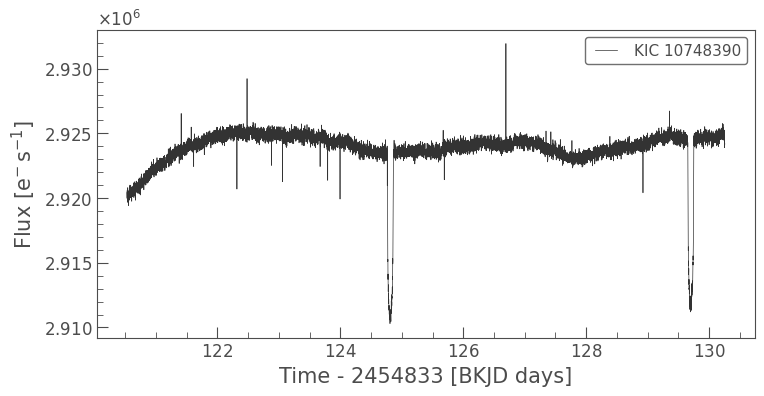

In [ ]:
lc.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

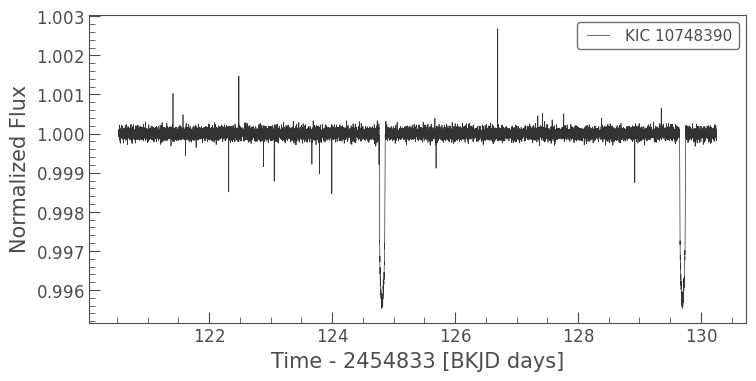

In [ ]:
clean_lc = lc.flatten()

clean_lc.plot()

<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

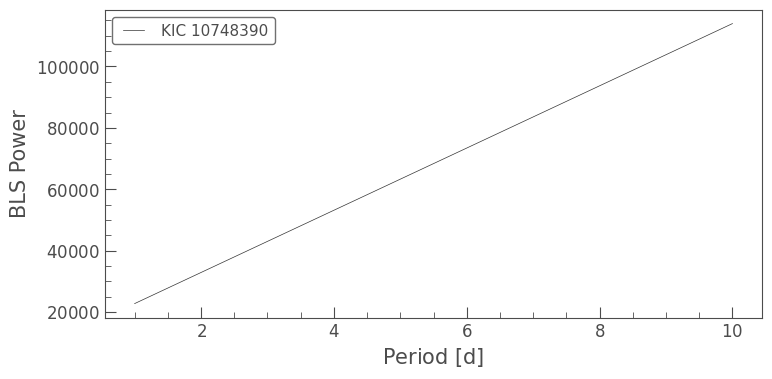

In [ ]:
periodogram = clean_lc.to_periodogram(method='bls', period=[1,10])

periodogram.plot()

In [ ]:
best_period = periodogram.period_at_max_power

print(best_period)

10.0 d


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

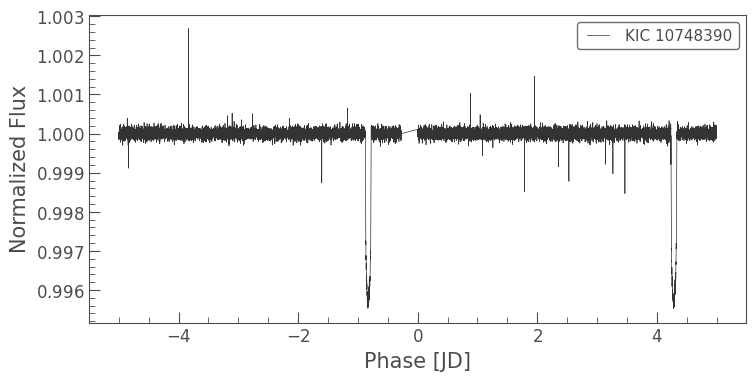

In [ ]:
folded_lc = clean_lc.fold(period=best_period)

folded_lc.plot()